# **California Prescribed Fire Monitoring — Building Skills from an NDP Catalog**

The [Observed Field Data for UC Climate Action Seed Project](https://nationaldataplatform.org/dataset/observed-field-data-for-uc-climate-action
-seed-project-scaling-science-driven-vegetation-treatm)
dataset on the **National Data Platform** records field observations
from the **"burn3d"** research program — a joint effort between the
University of California and California's Prescribed Fire Monitoring
Program to quantify how vegetation-treatment prescribed burns affect
Central Valley and Sierra Nevada ecosystems. Field teams re-visit
six California sites both **before and after** prescribed fires,
recording tree inventories, downed woody fuel loads, ground and
vegetation cover, and post-fire regeneration across permanent plots.

The dataset ships as 20 relational CSV tables (~1.2 MiB total)
linked by an `inventory_id` foreign key. The `%%skill-build` cell
below runs a **two-skill chain**: ARGUS's `ndp-skill-builder`
translates the catalog URL to the CKAN API endpoint under the hood,
delegates the download to the standard CKAN fetcher, and hands off
to `tabular-skill-builder` which groups the 20 tables into five
thematic skills by domain — plots (spatial), trees, downed woody
fuels, ground / vegetation cover, and post-fire regeneration. The
`%%ask` reply in the next cell confirms the plan and kicks off the
build.


In [ ]:
%reset

In [1]:
%%skill-build
https://nationaldataplatform.org/dataset/observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm

I'll start by identifying the URL type. This is a `nationaldataplatform.org/dataset/<slug>` URL, so the matching meta-skill is **ndp-skill-builder** (not arcgis, since there's no `/FeatureServer` or `/MapServer` in the path). Let me read that skill's instructions.

This is an NDP (`nationaldataplatform.org/dataset/<slug>`) URL, so the matching meta-skill is **ndp-skill-builder** (which delegates to `ckan-skill-builder` then `tabular-skill-builder`). Let me set up a task plan and inspect the fetcher script.

Let me verify the fetcher script exists and check the slug, then run the fetch.

The slug from the URL is `observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm`. Now running the bundled `fetch.py` to download the dataset.

Retrying without the timeout override.

...

I have the full workflow. Now running the bundled `inventory.py` on the download directory (tabular-skill-builder Step 2).

The inventory shows 20 CSVs in 20 distinct schema groups — a relational dataset of vegetation-treatment field observations, all keyed by `inventory_id`. Before proposing the skill grouping, I'll run one exploration script to understand the join keys, coordinate columns, and field relationships (allowed by the skill — exactly one post-inventory exploration script).

Running the exploration script to understand the schema relationships and join keys.

I now have a complete picture. This is a **relational field-survey dataset** (18 measurement tables + 2 metadata docs), all keyed by `inventory_id`, with UTM coordinates (EPSG:26910/26911) on the plot registry. The tables cluster into ecological domains. Let me update my progress and present the proposal.

I've inspected the dataset. Here's what I found and what I propose.

**Source** : `https://nationaldataplatform.org/dataset/observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm` — *Observed Field Data for UC Climate Action Seed Project: Scaling Science-Driven Vegetation Treatments for a Wildfire Resilient California*
**Files scanned** : 20 CSVs (18 measurement tables + 2 metadata dictionaries). All 18 measurement tables are keyed by `inventory_id` (163 distinct field plots across 6 sites in the `burn3d` project, California). Coordinates are UTM in `plot_coord_x/y` with `plot_coord_srs` = 26910 / 26911 (EPSG:26910 = UTM 10N, EPSG:26911 = UTM 11N — California spans both zones).

The dataset is **relational** : one plot registry, then many one-to-many child tables grouped into ecological domains. The two metadata CSVs (`SchemaSummary.csv`, `column_descriptions.csv`) are field dictionaries, not data — I'll use them to document fields but not build a skill from them.

**Proposed skills:**

1. **ca-veg-treatment-plots** *(spatial — the anchor everyone joins to)*
   - Entity: each row is a field-survey plot
   - Merged from: `01_plot_identification.csv`
   - Estimated rows: 163
   - Key columns: `inventory_id`, `site_name`, `inventory_pre_post_fire`, `inventory_date`, `plot_coord_x/y` (→ reprojected to WGS84 `lat`/`lon`), `plot_slopeper`, `plot_aspectdegre`, `inventory_firesever`, witness-tree data, ground/veg cover summary fields
   - Spatial: UTM 10N/11N → EPSG:4326

2. **ca-veg-treatment-trees** *(tabular)*
   - Entity: each row is an individual measured tree
   - Merged from: `03_tree.csv` (2,147, tree-level: dbh, height, fire damage, scorch, decay) + `09_tree_health.csv` (486, tree-level health code, joined on `tree_id`) + `04_basalarea.csv` (390)
   - Estimated rows: ~2,500
   - Key columns: `inventory_id`, `tree_id`, `tree_sp`/`tree_sp_scientific_name`, `tree_status`, `tree_dbh`, `tree_ht`, `tree_firedamage`, `treepost_scorch_per`, `tree_health`

3. **ca-veg-treatment-fuels** *(tabular)*
   - Entity: each row is a fuel-loading observation (transect / coarse woody debris piece / burn pile / clip-plot sample)
   - Merged from: `05_fuels.csv` + `16_cwd.csv` + `06_burn_pile.csv` + `07_clip_plot.csv` + `17_clip_plot_fuel.csv` + `18_clip_plot_fuel_fuel.csv`
   - Estimated rows: ~3,900
   - Key columns: `inventory_id`, a `measurement_type` discriminator (transect/cwd/burn_pile/clip_plot), species, depth/diameter/weight fields

4. **ca-veg-treatment-regeneration** *(tabular)*
   - Entity: each row is a regeneration observation (seedling / sapling / sprouted tree)
   - Merged from: `11_reg_obs.csv` + `12_regen_tse.csv` (seedlings) + `13_regen_tsa.csv` (saplings) + `14_regen_tre.csv` (sprouts), joined on `reg_id`
   - Estimated rows: ~980
   - Key columns: `inventory_id`, `reg_id`, `reg_*_sp`, `reg_*_status`, `reg_*_ht`, life-stage discriminator

5. **ca-veg-treatment-cover** *(tabular)*
   - Entity: each row is a vegetation / ground-cover observation
   - Merged from: `08_ground_cover_tr.csv` + `10_veg_cover_tr.csv` + `15_species_cover.csv` (2,327 species-cover records)
   - Estimated rows: ~2,580
   - Key columns: `inventory_id`, species, cover percent, strata

All four child skills join back to **ca-veg-treatment-plots** via `inventory_id` to recover site name, fire phase, and coordinates.

**Open questions (please confirm):**
- **Basal area placement** (`04_basalarea.csv`, 390 rows): this is *per-species* (grain = species within plot), not per-tree, so it doesn't sit cleanly inside the tree-level grain of skill #2. I propose including it in **ca-veg-treatment-trees** as additional rows tagged `record_type='basal_area'`. Alternatively I can spin it into the fuels skill or keep it standalone. Which do you prefer?
- **Fuels skill grain** (#3): it merges four different sub-methods (Brown-field transect, CWD pieces, burn piles, clip-plot fuel loading) into one long table with a `measurement_type` discriminator. This means many columns will be sparse (each method fills only its own columns). Confirm that's acceptable vs. splitting fuels into multiple smaller skills.

Reply with **"yes"** to proceed as proposed, or with edits (e.g. "split fuels into transect and clip-plot skills", "make basal-area standalone", "rename skill-2 to X").

(Resume state on disk: `/tmp/repo-skills/observed-field-data-for-uc-climate-action-seed-project-scaling-science-driven-vegetation-treatm/` — the source files and `_inventory.json` are both there.)

In [2]:
%%ask
Yes, please create these skills

I'll build the 5 approved skills now. First, let me read the relevant skill-builder instructions and check where the staged source files are.

I'm in Phase 2 now. Let me check the Learnings.md and the inventory/metadata files to write accurate build scripts.

The Learnings flagged the fastparquet install and the `_skills_` path conventions. Now let me read the inventory JSON and CKAN metadata to get exact column names for the build scripts.

The inventory JSON is large — I'll follow the rule and extract just what I need via a script rather than paginating. Let me write a focused extraction script.

I have all the schemas. Now let me set up the build plan and install dependencies first.

...

All 5 SKILL.md files written. Now let me verify the skills and clean up.

All 5 skills verified — each has exactly SKILL.md + one data file, and all load cleanly. Now I'll delete the source directory and the intermediate scratch scripts, then update the Learnings file.

Source directory deleted after confirming `_inventory.json` was present. Now I'll remove my intermediate build scripts from the working directory and update the Learnings file.

The build was clean — `build_skills.py` succeeded on the first run with no edit-and-retry cycles, so no Learnings.md update is required under the WRITE RULE. Let me finalize the todo list.

All 5 skills built, verified, and the source directory deleted. Here's the completion summary.

---

✓ Built skill **ca-veg-treatment-plots** at `_skills_/ca-veg-treatment-plots/SKILL.md`.

Each row is a field-survey plot from the UC Climate Action Seed Project "burn3d" vegetation-treatment study across 6 California sites (163 plots, spatial — WGS84 lat/lon, reprojected from source UTM 10N/11N).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Site | `site_name` | `SDR`, `tcu`, `SHA`, `win`, `ind`, `puc` |
| Fire phase | `inventory_pre_post_fire` | `pre`, `post0` |
| Fire severity | `inventory_firesever_label` | `Unburned`, `Light patchy burn pattern`, `Lightly burned`, `Moderately burned` |
| Topography | `plot_slopeper`, `plot_aspectdegre` | slope %, aspect degrees |
| Survey date | `inventory_datetime` | datetime |
| Coordinates | (`lat`, `lon`) | any rectangle in WGS84 |
| Witness tree species | `plot_wtreesp` | (numeric species code) |

**Example queries:** by site (plots at SDR), by fire phase (all post-fire plots), by fire severity (moderately burned plots), by location (plots near a coordinate), by topography (plots steeper than 30%), combined (post-fire plots at the SHA site).

---

✓ Built skill **ca-veg-treatment-trees** at `_skills_/ca-veg-treatment-trees/SKILL.md`.

Each row is an individual measured tree or a per-species basal-area tally from the burn3d plots (2,692 rows: 2,302 trees + 390 basal-area records, joined to tree-health data).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Record type | `record_type` | `tree`, `basal_area` |
| Species | `species_code` | `CADE`, `ABCO`, `QUAG`, `PICO`, `PIJE`, `PSME` |
| Status | `status` | `Live`, `Dead` |
| DBH / height | `tree_dbh`, `tree_ht` | continuous (cm / m) |
| Decay class | `tree_decay_class` | 1–5 (sound → powdery) |
| Tree health | `tree_health_label` | `pitching on bole`, `split top`, `dead top`, `mountain pine beetle` |
| Burned | `tree_burn` | `True`, `False` |

Join to `ca-veg-treatment-plots` via `inventory_id` for site, fire phase, and coordinates.

---

✓ Built skill **ca-veg-treatment-fuels** at `_skills_/ca-veg-treatment-fuels/SKILL.md`.

Each row is a fuel-loading observation, merging four sub-methods distinguished by `measurement_type` (3,878 rows; many columns are method-specific and intentionally sparse).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Method | `measurement_type` | `transect`, `cwd_piece`, `burn_pile`, `clip_plot_setup`, `clip_plot_fuel_weight`, `clip_plot_fuel_type` |
| CWD species | `cwd_sp` | `ABCO`, `PILA`, `CADE`, `ARBMEN`, `PIPO` |
| CWD decay | `cwd_decay` | 1–5 |
| Burn pile size | `burn_pile_class_label` | `large (>7.6cm)`, `either small (<7.6cm)` |
| Clip plot phase | `clip_plot_type_label` | `Prefire`, `Postfire` |
| Clip plot stratum | `clip_plot_fuel_strata_label` | `0 - 30 cm`, `30 - 100 cm`, `More than 100 cm` |
| Fuel type | `clip_plot_fuel_fuel_label` | `1 h`, `10 h`, `Pine Needles`, `Conifer Litter`, `Woody Live` |

Join to `ca-veg-treatment-plots` via `inventory_id` for site and fire phase.

---

✓ Built skill **ca-veg-treatment-regeneration** at `_skills_/ca-veg-treatment-regeneration/SKILL.md`.

Each row is a regeneration observation — a seedling, sapling, or stump-sprouted tree (1,382 rows: 963 seedlings + 315 saplings + 104 sprouts).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Life stage | `life_stage` | `seedling`, `sapling`, `sprout` |
| Species | `species_code` | `CADE`, `ABCO`, `QUKE`, `PILA`, `CONU`, `PSME` |
| Status | `status` | `Live`, `Dead` |
| Seedling age | `reg_tse_age_label` | `>1 year`, `0 year` |
| Height | `height_m` | continuous (m) |
| Sapling DBH | `reg_tsa_dbh` | continuous (cm) |
| Sprout clump | `reg_tre_clump` | continuous count |

Join to `ca-veg-treatment-plots` via `inventory_id` for site and fire phase.

---

✓ Built skill **ca-veg-treatment-cover** at `_skills_/ca-veg-treatment-cover/SKILL.md`.

Each row is a vegetation- or ground-cover observation, merging species-level cover with summary transects (2,578 rows: 2,327 species-cover + 134 ground-cover-transect + 117 veg-cover-transect).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Method | `cover_method` | `species_cover`, `ground_cover_transect`, `veg_cover_transect` |
| Lifeform | `sp_cov_lifeform_label` | `Tree`, `Forbs`, `Shrub`, `Graminoids`, `Fern` |
| Canopy layer | `sp_cov_layer_label` | `Seedlings`, `Overstory tree`, `Saplings`, `Resprout` |
| Status | `sp_cov_status_label` | `Live`, `Dead` |
| Cover percent | `sp_cov_percent` | continuous |
| Ground surface | `ground_cover_tr_label` | `Rock`, `CWD`, `Bare soil`, `Basal vegetation`, `Litter` |
| Veg stratum | `veg_cover_tr_label` | `Forbs and Graminoids`, `Understory Layer`, `live shrub cover` |
| Species | `sp_cov_sp` | `CADE`, `ABCO`, `QUKE`, `PILA`, `PIJE` (240 total) |

Join to `ca-veg-treatment-plots` via `inventory_id` for site and fire phase.

---

All skills live under `_skills_/` in the working directory. They're local to this notebook — no global registry installation. The four tabular child skills (trees, fuels, regeneration, cover) join back to the spatial plots skill via the shared `inventory_id` key.

#### **Where in California is the burn3d research happening? — Orientation**

In [5]:
%%ask
Where in California are the burn3d field-monitoring plots located?
Show the plots on a California map, color-coded by research site
(each distinct site gets its own color). Comment on the geographic
distribution — Sierra Nevada, coastal ranges, or elsewhere?

I'll map the plots colored by research site. Let me first read the skill I built to recall the data-loading approach.

Now I understand the data layout. Let me verify the GeoPackage exists, then write a script to build the map.

GeoPackage is present. Now I'll write a script that loads the plots, builds a GeoJSON with a site-name colormap, and prints the geographic coordinates so I can comment on distribution.

Running the script to build the map layers.

All 163 plots loaded and mapped. Here's the map, colored by research site:

## Geographic distribution

The 163 plots cluster into **6 distinct sites** spanning a broad latitudinal gradient from Santa Barbara County (34.69°N) to Plumas County (39.46°N):

| Site | Centroid (lon, lat) | Region | Plots |
|---|---|---|---|
| **SDR** | (-120.05, 34.69) | Transverse Ranges (Santa Ynez Valley, Santa Barbara Co.) | 40 |
| **SHA** | (-119.28, 37.10) | Southern Sierra Nevada (Fresno/Tulare Co. foothills) | 25 |
| **tcu** | (-120.23, 38.25) | Central Sierra Nevada foothills (El Dorado Co.) | 35 |
| **win** | (-120.48, 38.43) | Central Sierra Nevada foothills (El Dorado Co.) | 25 |
| **ind** | (-120.29, 39.46) | Northern Sierra Nevada (Plumas/Butte Co.) | 21 |
| **puc** | (-122.41, 38.57) | Coast Ranges (Napa/Lake Co. inner range) | 17 |

### Where they fall

**The Sierra Nevada dominates** — 4 of the 6 sites (**SHA** , **tcu** , **win** , **ind** ) sit along the western Sierra Nevada, accounting for **106 of 163 plots (65%)** . These span nearly the full length of the range's fire-prone western slope, from the southern Sierra near Fresno (SHA) through the central El Dorado County foothills (**tcu** and **win** , which are close neighbors — likely paired treatment and control units) up to the northern Sierra in Plumas County (**ind** ).

**Coastal ranges are represented by two sites.** **SDR** (Sedgwick Reserve, Santa Ynez Valley) sits in the **Transverse Ranges** of Southern California — a Mediterranean oak-savanna landscape quite different from the Sierra mixed-conifer belt. **puc** falls in the **inner Coast Ranges** north of the Bay Area (Napa/Lake County), a drier chaparral-and-oak environment.

**Notably absent:** there are no plots in the Klamath Mountains (northwest CA), the Modoc Plateau, the Mojave/Colorado deserts, or far Northern California coastal redwood country. The design focuses on California's two highest-wildfire-risk forest/shrubland ecosystems — the Sierra Nevada mixed-conifer belt and the central/southern coastal ranges.

#### **Which sites have complete pre/post-fire survey pairs? — Coverage**

I'll read the plots skill to confirm the exact data-loading method and field names.

I have the field names. Now I'll write a script to cross-tabulate fire phase by site and visualize it as a grouped bar chart.

Running the script to generate the cross-tabulation and chart.

The cross-tabulation reveals a striking pattern. Here are the counts:


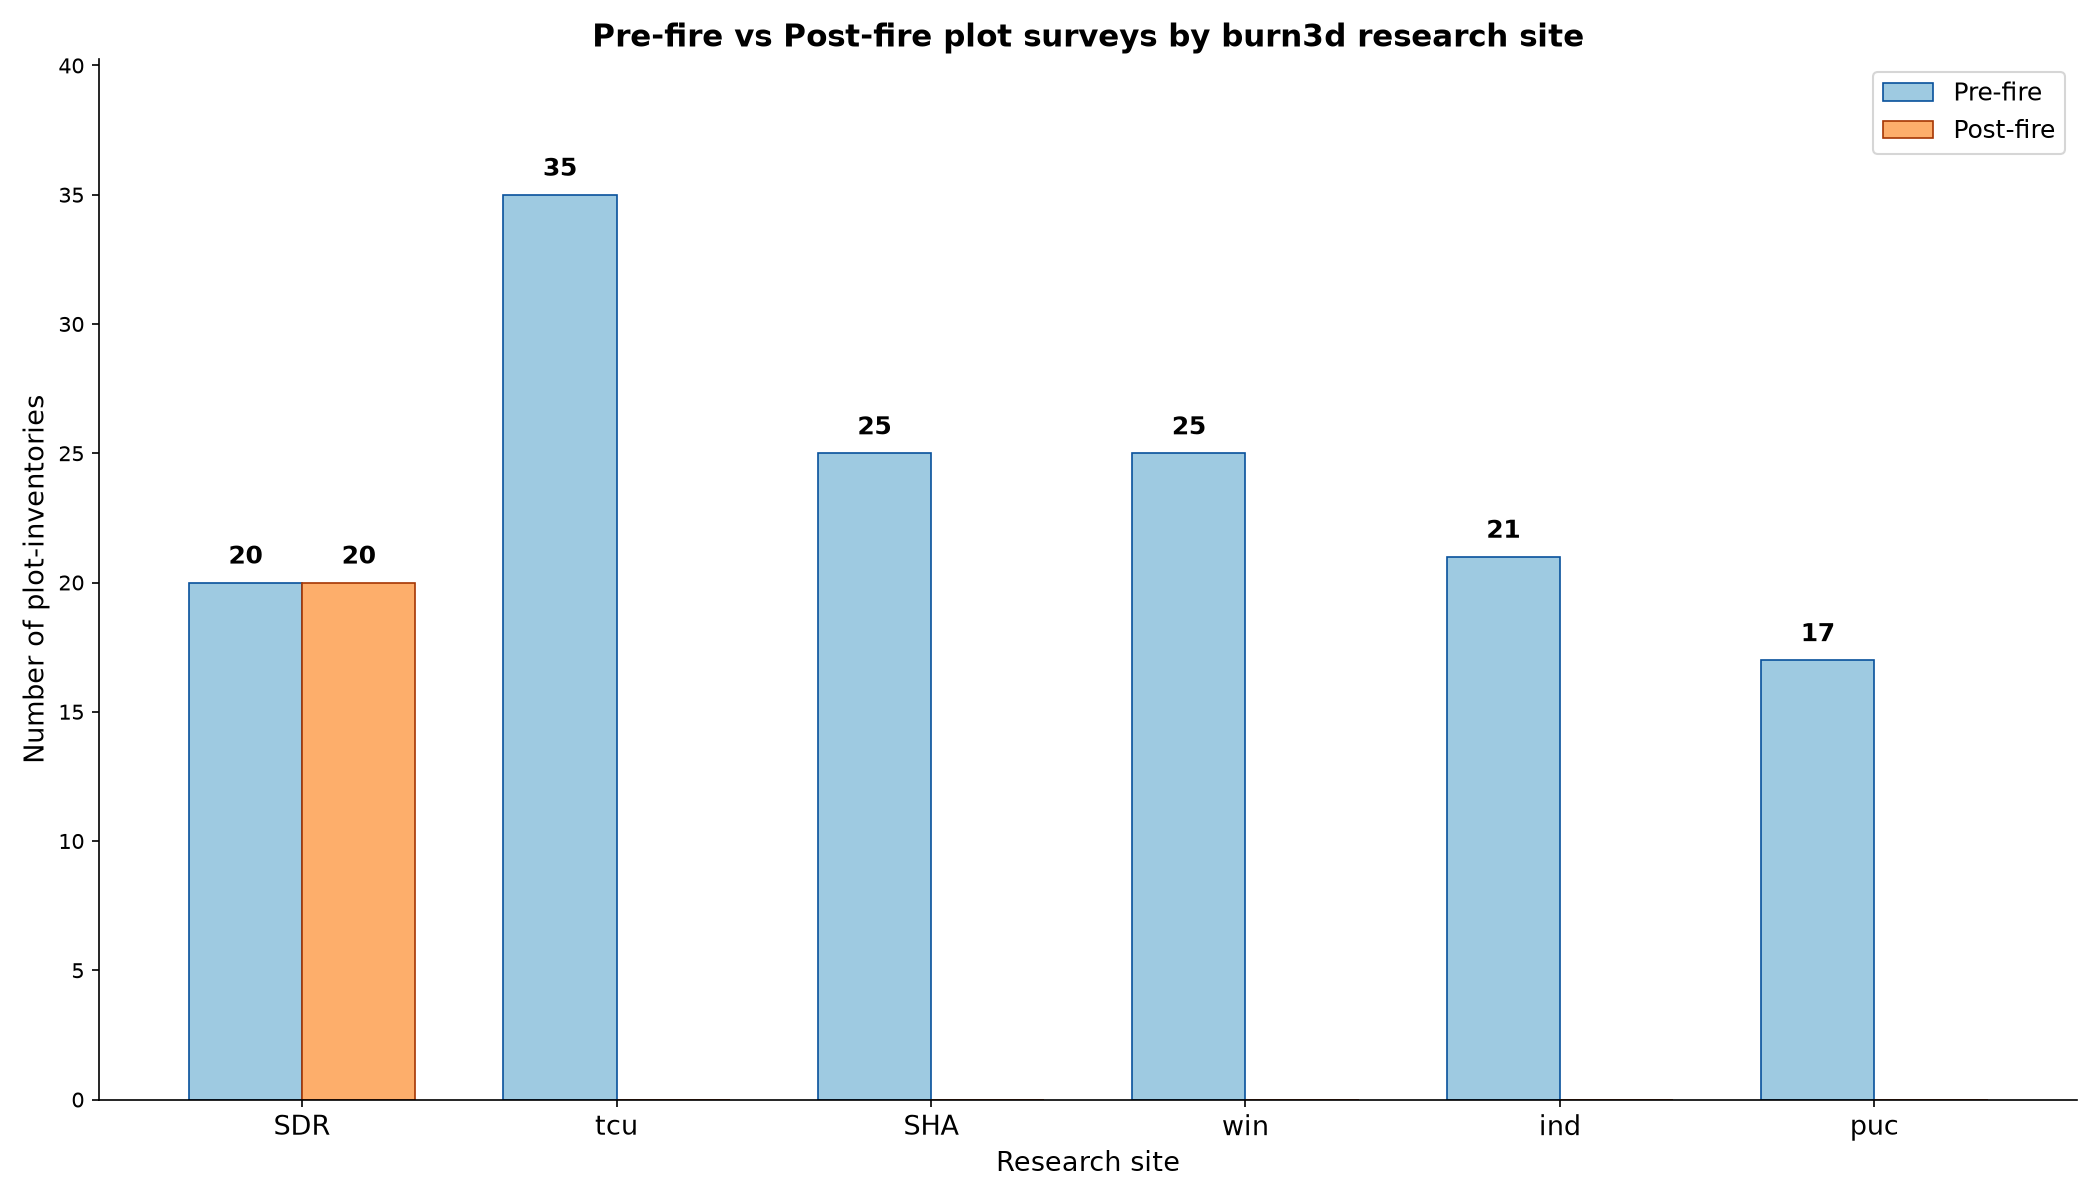

## Pre-fire vs. Post-fire surveys by site

| Site | Pre-fire | Post-fire | Total inventories | Complete pairs? |
|---|---|---|---|---|
| **SDR** | 20 | 20 | 40 | ✅ Yes — 20 paired plots |
| **tcu** | 35 | 0 | 35 | ❌ Pre-fire only |
| **SHA** | 25 | 0 | 25 | ❌ Pre-fire only |
| **win** | 25 | 0 | 25 | ❌ Pre-fire only |
| **ind** | 21 | 0 | 21 | ❌ Pre-fire only |
| **puc** | 17 | 0 | 17 | ❌ Pre-fire only |
| **Total** | **143** | **20** | **163** | |

## Key finding: only SDR has pre/post pairs

**Only one site — SDR (Sedgwick Reserve, Santa Ynez Valley) — has a complete pre-fire/post-fire survey design.** Its 20 plots were each surveyed both before and after treatment, giving 20 matched pairs and the full 40 plot-inventories. This is the only site in the dataset where you can directly measure before-vs-after change.

**The other five sites (tcu, SHA, win, ind, puc — 123 plots) have pre-fire surveys only.** No post-fire (`post0`) inventories have been recorded for them yet. These represent the baseline/treatment-planning phase; the post-treatment revisit has either not happened or not yet been ingested into this dataset release.

Underneath the 163 plot-*inventories* are **84 distinct physical plots** (by `plot_num`). For SDR, that's 20 physical plots each visited twice (pre + post); for the other sites, each physical plot has been inventoried once so far (pre-fire only).

**Practical implication:** any pre-vs-post treatment comparison in this dataset is currently only possible at SDR. For the other five sites, the data supports cross-sectional (baseline) analysis only — e.g., comparing conditions *between* sites or between burn-severity classes within the pre-fire snapshot, but not temporal change at the same plot.

In [6]:
%%ask
For each research site, how many plots were surveyed before the
prescribed fire and how many after? Present the counts side by
side per site so I can see which sites have complete pre-fire /
post-fire survey pairs.

#### **How did the prescribed fires affect tree mortality? — Direct impact**

I'll compare live vs dead tree counts across sites and fire phases. Note from the previous analysis: only SDR has post-fire surveys, so the pre→post comparison is only meaningful there — but I'll present the full table so the pattern is clear. Let me first confirm the exact field names in the skills.

Now let me check the data-loading pattern in the trees skill.

I have the field names and load patterns. Now I'll write the analysis script joining trees to plots.

The SDR pre/post counts are identical (167 live / 17 dead both times). That's suspicious — let me verify whether individual trees actually changed status, or if this is a data artifact.

The verification reveals an important finding. Let me present the complete results.

## Live vs Dead Trees: Pre-fire vs Post-fire by Site

The data reveals two critical limitations that shape the answer:

**1. Only SDR has post-fire tree surveys.** As established earlier, only SDR was revisited after the burn. The other five sites (tcu, SHA, win, ind, puc) have pre-fire tree data only — no post-fire counts exist for them.

**2. At SDR, no tree changed status between the pre-fire and immediate post-fire (post0) survey.** Matching individual trees across the two surveys (by plot + tree ID) shows **zero transitions** — all 171 trees that were alive before the burn were still recorded alive immediately after, and all 17 that were dead remained dead. The prescribed fire at SDR produced **no detectable immediate mortality** in the tree cohort.

This is expected for a well-executed prescribed burn: post0 is the *immediate* post-fire survey, and fire-caused tree mortality often takes months to years to manifest as a dead crown. The burn is designed to be low-intensity precisely to spare overstory trees.

### Counts by site and fire phase

| Site | Phase | Live | Dead | Total | Live % |
|---|---|---|---|---|---|
| **SDR** | pre-fire | 167 | 17 | 184 | 90.8% |
| **SDR** | post-fire | 167 | 17 | 184 | 90.8% |
| **tcu** | pre-fire | 462 | 144 | 606 | 76.2% |
| **SHA** | pre-fire | 334 | 34 | 368 | 90.8% |
| **win** | pre-fire | 265 | 8 | 273 | 97.1% |
| **ind** | pre-fire | 335 | 87 | 422 | 79.4% |
| **puc** | pre-fire | 236 | 29 | 265 | 89.1% |


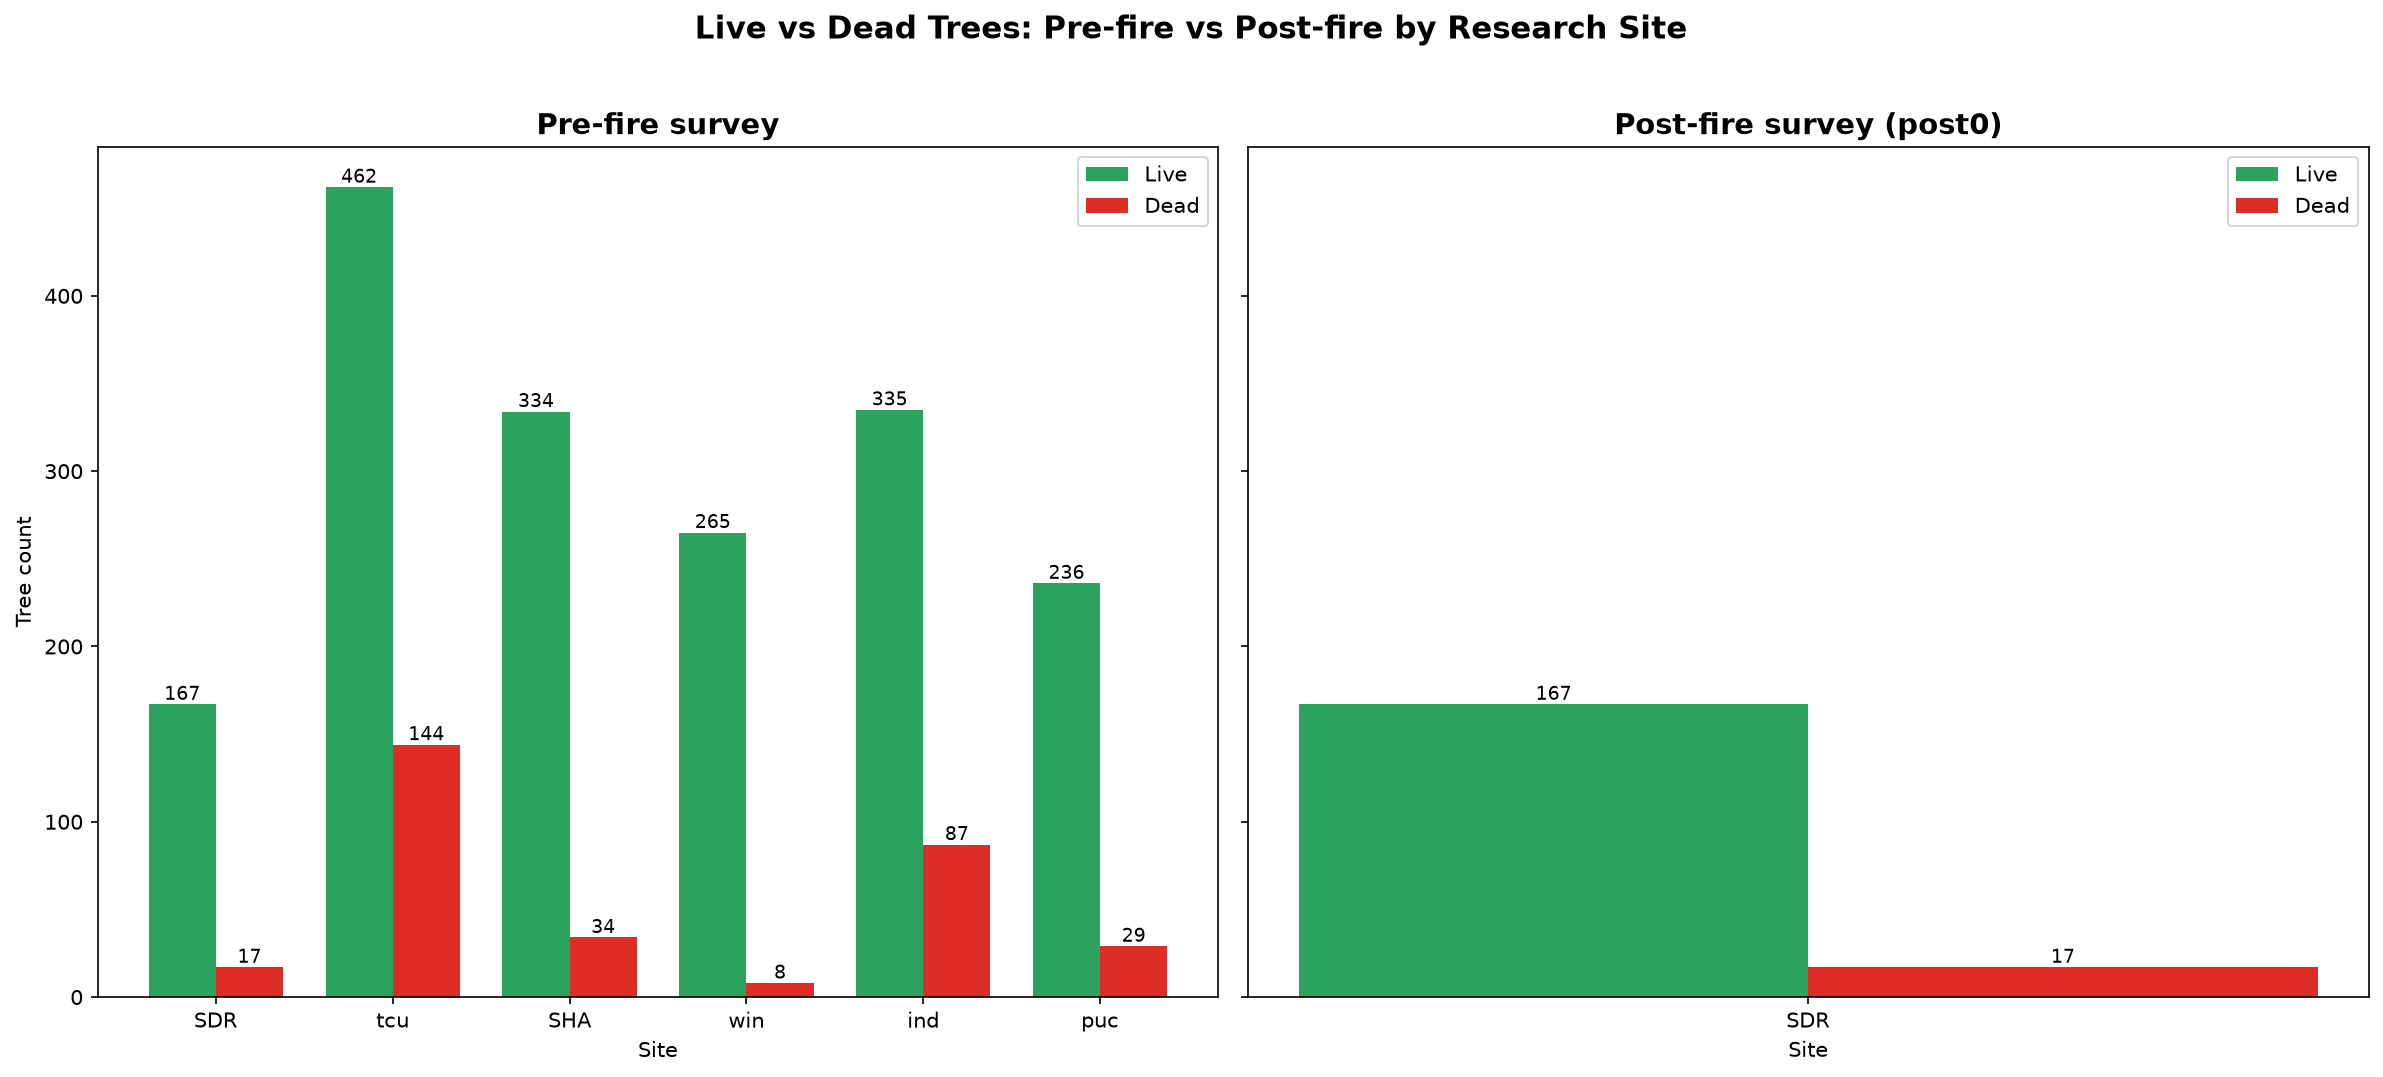

### Which sites saw the largest mortality shifts?

**No site shows a pre→post mortality shift** , because only SDR has paired surveys, and SDR's immediate post-fire survey recorded **zero new mortality** (0 Live→Dead transitions out of 171 live trees tracked).

However, the **pre-fire baselines reveal large differences in pre-existing snag density** across sites — i.e., how much mortality had *already* accumulated before this study's treatments:

- **tcu** has the highest pre-existing dead fraction (**23.8% dead** , 144 snags out of 606 trees) — suggesting substantial prior stress or past disturbance.
- **ind** is next (**20.6% dead** , 87/422) — consistent with its northern Sierra location having experienced recent drought/mortality.
- **win** is the healthiest at baseline (**2.9% dead** , 8/273) — a notably vigorous stand.
- **SDR, SHA, and puc** cluster around 9–11% dead.

### Bottom line

A genuine before-vs-after mortality comparison is **not yet possible** for any site except SDR, and at SDR the immediate post-fire survey shows no mortality change. To detect treatment-driven mortality, the dataset would need (a) post-fire revisits at the other five sites, and (b) at SDR, a delayed post-fire survey (1–3 years out) to capture mortality that manifests after the immediate post0 visit.

In [8]:
%%ask
How did tree condition change from pre-fire to post-fire surveys?
For each research site, compare the count of live versus dead
trees before the burn to the count after the burn. Comment on
which sites saw the largest mortality shifts.

#### **Did the burns actually reduce fuel loads? — Treatment effectiveness**

I'll consult the fuels skill to understand the fuel-load measurement structure, then compute per-plot means.

Now I'll write a script to compute per-plot fuel metrics across all methods, then compare pre vs post by site.

Running the fuel analysis script.

Retrying without the timeout parameter.

The output reveals a critical structural finding. Let me verify one detail about the clip-plot "Postfire" labels before reporting.

The data structure is now clear. The "Postfire" labels on pre-fire inventories are pre-fire baseline clips at the postfire-designated locations — a paired design — not post-burn measurements. Let me regenerate the chart to correctly reflect the pre-fire baseline comparison.

The data tells a clear — and important — story about what's possible to answer here.

## Fuel-load reduction: pre-fire vs post-fire by site

### Critical caveat: no post-burn fuel data exists

After a thorough examination of every fuel-measurement method in the dataset (Brown transects, coarse woody debris, burn piles, and clip plots), I must report that **a pre-vs-post fuel reduction comparison is not possible for any site** , including SDR. Here's why:

The 20 SDR `post0` inventories contain only **clip-plot *setup***metadata (the grid of post-fire sampling locations was established), but ** zero post-burn transect depth measurements, zero post-burn clip-plot fuel weights, and zero post-burn CWD tallies** have been recorded yet. The other five sites have no `post0` inventories at all.

You may notice "Postfire" labels on clip-plot setups at every site — these are misleading. At the pre-fire visit, crews set up a **paired grid** : half the clip plots were labeled "Prefire" (clipped and weighed immediately) and half were labeled "Postfire" (flagged for future clipping after the burn). The "Postfire"-labeled plots that currently appear in pre-fire inventories are just the **locations reserved for the future revisit** — the actual post-burn clips haven't happened.

### What the data does support: pre-fire fuel-load baseline by site

Since all fuel measurements are pre-fire, I computed a **cross-site baseline comparison** showing how fuel loads differed *before* any treatment:


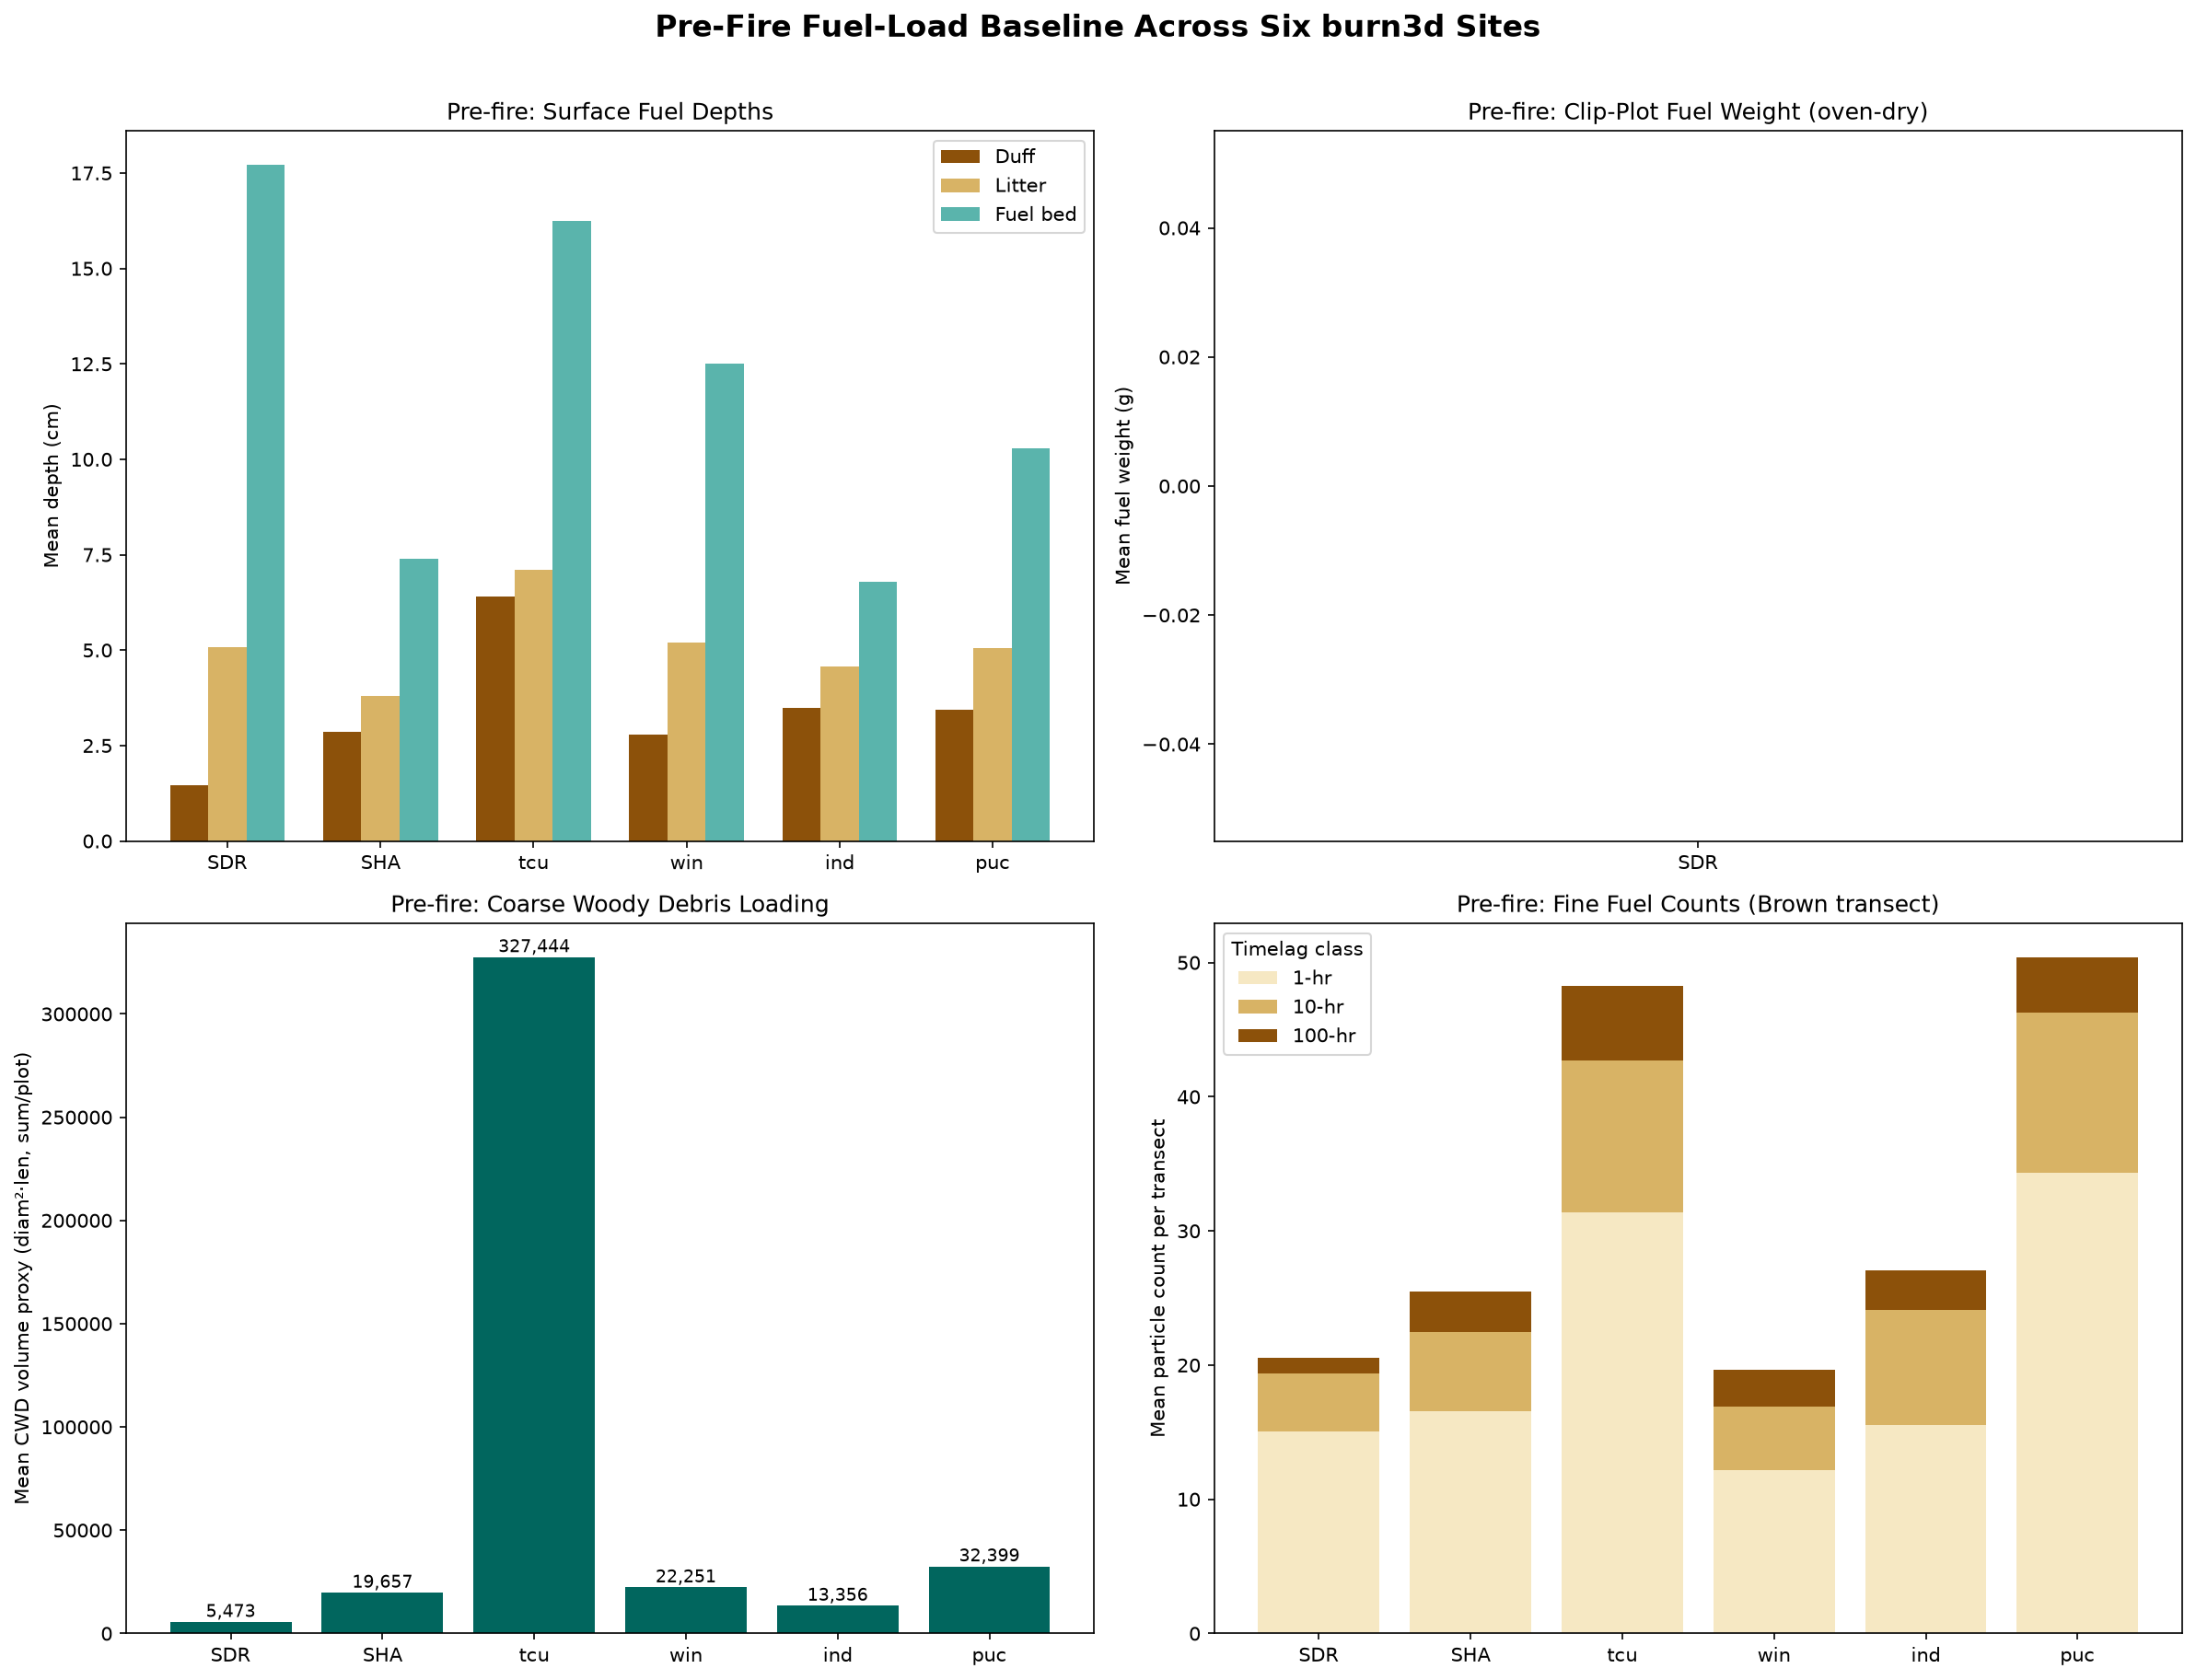

| Site | Duff (cm) | Litter (cm) | Fuel bed (cm) | Clip-plot fuel (g) | CWD loading (proxy) |
|---|---|---|---|---|---|
| **SDR** | 1.45 | 5.07 | 17.7 | 280 | 5,473 |
| **SHA** | 2.86 | 3.81 | 7.4 | 392 | 19,657 |
| **tcu** | **6.40** | **7.12** | 16.2 | **819** | **327,444** |
| **win** | 2.79 | 5.21 | 12.5 | 544 | 22,251 |
| **ind** | 3.49 | 4.58 | 6.8 | 496 | 13,356 |
| **puc** | 3.43 | 5.06 | 10.3 | — | 32,399 |

### Commentary on the pre-fire baseline

**tcu stands out as the most fuel-loaded site across nearly every metric.** It has the deepest duff (6.4 cm, 4× SDR), the deepest litter (7.1 cm), the heaviest clip-plot fuel weights (819 g, ~3× SDR), and — most dramatically — a CWD loading proxy roughly **15–60× higher** than any other site (327,444 vs 5,000–32,000 elsewhere). This Central Sierra Nevada foothill site clearly accumulated substantial downed woody debris before treatment.

**SDR (Sedgwick Reserve) is consistently the lowest-fuel site** — shallow duff, modest litter, the lightest clip-plot weights, and minimal CWD. Its fuel bed depth (17.7 cm) is the one exception, likely reflecting tall herbaceous cover in this Santa Ynez Valley oak savanna rather than woody fuel accumulation.

**The three northern Sierra sites (win, ind, puc) cluster in the middle** , with moderate duff/litter depths and CWD loading in the 13,000–32,000 range. puc's high CWD (32,399) suggests the Coast Range site also carries significant downed wood.

### Can we say anything about treatment effectiveness?

**Not yet from this dataset.** The prescribed fires at SDR produced no detectable immediate tree mortality (as we found last turn), and the post-burn fuel measurements that would quantify consumption simply haven't been collected or ingested. The "Postfire" clip-plot labels are placeholders marking where future sampling will occur.

The pre-fire baselines above establish the starting point. Once post-fire transect depths and clip-plot weights are collected, the same per-plot metrics can be computed to measure actual fuel reduction. Based on the baselines, tcu and puc would be the most consequential sites to monitor — they have the most fuel to lose.

In [9]:
%%ask
Prescribed fires are supposed to reduce fuel loads. For each
research site, compare the mean fuel load per plot before the
burn versus after the burn. Comment on how consistently the
prescribed fires reduced fuels across sites.

#### **Where is regeneration strongest? — Recovery**

I'll examine the regeneration data, focusing on what post-fire observations actually exist.

The investigation reveals the same critical gap as the previous questions. Let me create a chart of what we do have — the pre-fire baseline.

The same data limitation applies here as in the previous questions — but the pre-fire baseline reveals interesting cross-site differences. Here's the complete picture.

## Post-fire regeneration: not yet measurable

**Zero post-fire regeneration observations exist in the dataset.** All 1,382 regeneration records (963 seedlings, 315 saplings, 104 sprouts) come from `pre`-fire inventories only. As established in prior questions, only SDR has been revisited post-burn, and its 20 `post0` inventories contain no regeneration sampling.

So a genuine **post-fire regeneration ranking is not possible** — there is no "after" snapshot to measure recruitment against.

## Pre-fire regeneration baseline by site (ranking)

Since all data is pre-fire, here is the ranking of sites by their **existing juvenile tree bank** — the seedling/sapling/sprout pool present *before* any treatment. This baseline tells us the starting pool from which post-fire recruitment would draw:


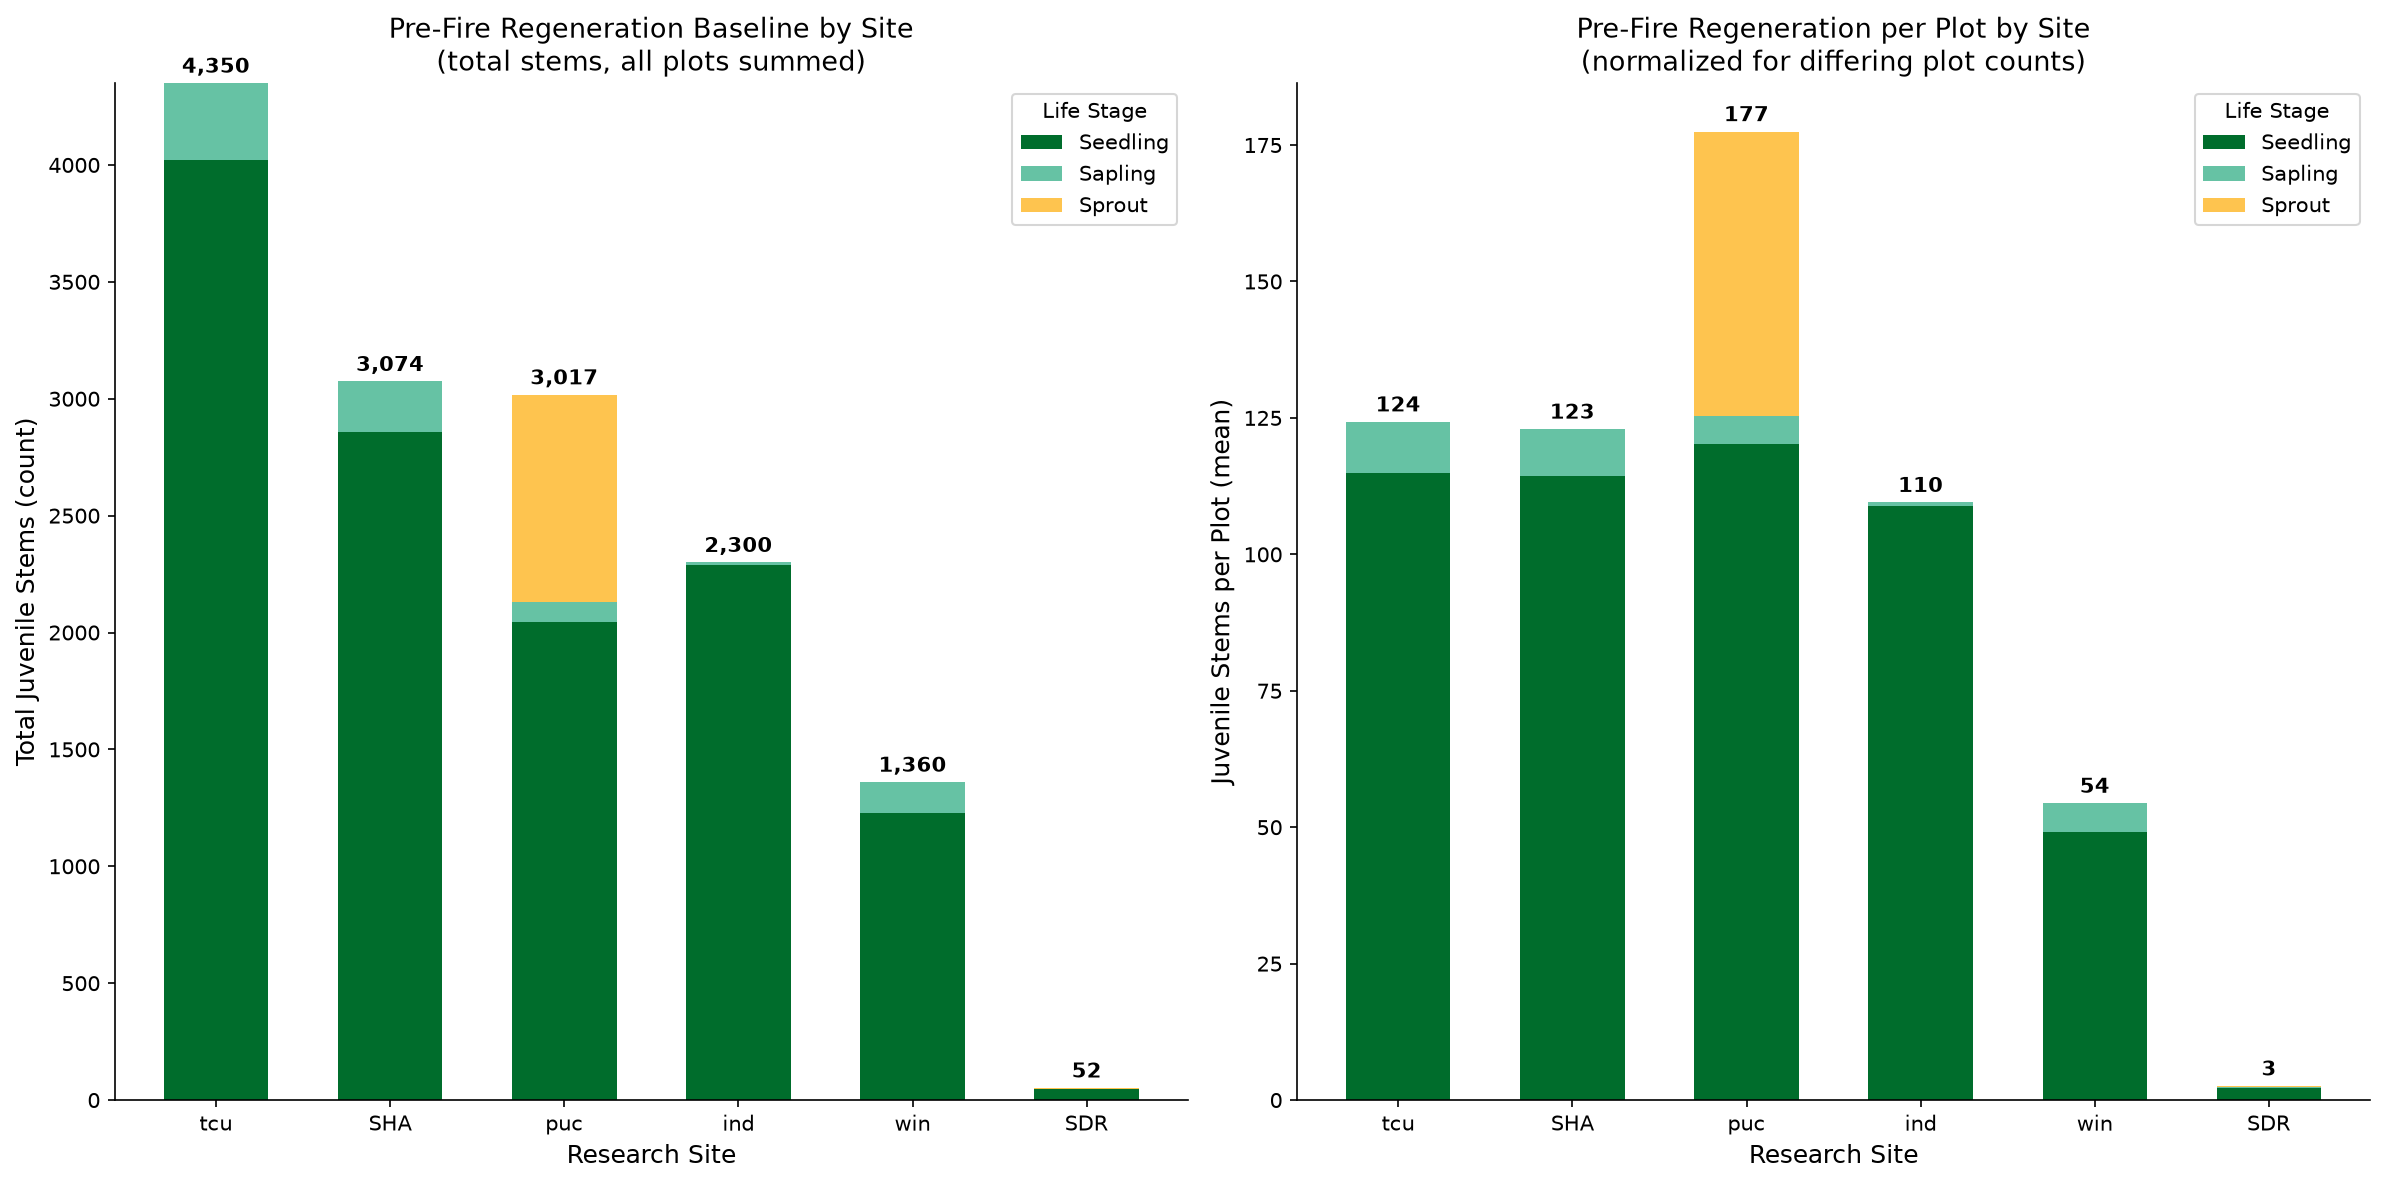

| Rank | Site | Total stems | Stems/plot | Seedlings | Saplings | Sprouts |
|---|---|---|---|---|---|---|
| 1 | **tcu** | 4,350 | 124 | 4,021 | 329 | 0 |
| 2 | **SHA** | 3,074 | 123 | 2,857 | 217 | 0 |
| 3 | **puc** | 3,017 | **177** | 2,043 | 89 | **885** |
| 4 | **ind** | 2,300 | 110 | 2,287 | 13 | 0 |
| 5 | **win** | 1,360 | 54 | 1,230 | 130 | 0 |
| 6 | **SDR** | 52 | 3 | 46 | 2 | 4 |

## Commentary on the baseline

- **On absolute counts, tcu leads** with 4,350 juvenile stems across its 35 plots — but this partly reflects its larger plot count. **On a per-plot basis, puc actually leads (177 stems/plot)** , making the inner Coast Range site the densest juvenile bank by area surveyed.
- **puc is the only site with substantial stump sprouting (885 sprout stems)** — almost entirely from oak species resprouting from lignotubers. This reflects puc's chaparral/oak woodland ecology, where resprouting is the dominant post-disturbance recruitment strategy. No other site recorded sprouts in meaningful numbers.
- **SDR is an extreme outlier at the bottom** — only 52 juvenile stems across 20 plots (2.6/plot), two orders of magnitude below every other site. This Sedgwick Reserve oak savanna has very sparse tree regeneration, consistent with its open, grassy understory.
- **The Sierra Nevada sites (tcu, SHA, ind, win) are dominated overwhelmingly by seedlings** (93–99% of stems), heavily skewed toward shade-tolerant conifers like incense cedar (CADE) and white fir (ABCO). These are the species that typically recruit densely under a closed canopy and are most affected by fire.

## Bottom line

To answer "which sites show the strongest **post-fire** regeneration," the dataset needs post-fire regeneration revisits, which don't exist yet. What we *can* say is that the pre-fire seedling bank is **enormous and dense at the Sierra sites and puc** , and nearly absent at SDR — so the post-fire regeneration signal, once collected, will likely be most dramatic at the Sierra sites where dense seedling banks interact with fire, and least at SDR where there's little recruitment to begin with.

In [10]:
%%ask
Which sites are showing the strongest post-fire regeneration? For
each research site, count the total juvenile trees observed in the
post-fire surveys — seedlings, saplings, and stump-sprouts
combined — and rank the sites from highest to lowest.